In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import pickle
sys.path.append(os.path.abspath('..'))
from mounirood.framework import FrameworkFactory
from mounirood.datasets import get_y, get_dataloader
from mounirood.eval_functions import train, visualize, auc_and_fpr_recall, separabilite, calc_acc, performance_report


import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Création du dataset

In [3]:
with open('../_classifieur/classif_react/data_near.pkl', 'rb') as f:
    data_react = pickle.load(f)

with open('../_classifieur/classif_ash/data_near.pkl', 'rb') as f:
    data_ash = pickle.load(f)
    
data_all = {}

for dataset in data_react.keys():
    data = {}
    data["X_train"] = np.hstack([data_react[dataset]["X_train"], data_ash[dataset]["X_train"][:,1:]])
    data["X_test"] = np.hstack([data_react[dataset]["X_test"], data_ash[dataset]["X_test"][:,1:]])
    data["y_train"], data["y_test"] = data_ash[dataset]["y_train"], data_ash[dataset]["y_test"]
    data_all[dataset] = data

with open('data_near_ar.pkl', 'wb') as f:
    pickle.dump(data_all, f)

# Near OOD

In [5]:
with open('data_near_ar.pkl', 'rb') as f:
    data_all = pickle.load(f)
    

## HMDB

In [7]:
data = data_all["HMDB"]
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 
input_dim = 7 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data['y_train'], return_counts=True) ### Entrainement avec pondération)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

3362 elements (array([0., 1.], dtype=float32), array([ 367, 2995]))
841 elements (array([0., 1.], dtype=float32), array([ 92, 749]))


0.12253756260434057

cuda
accuracy train:  0.6843511705045346


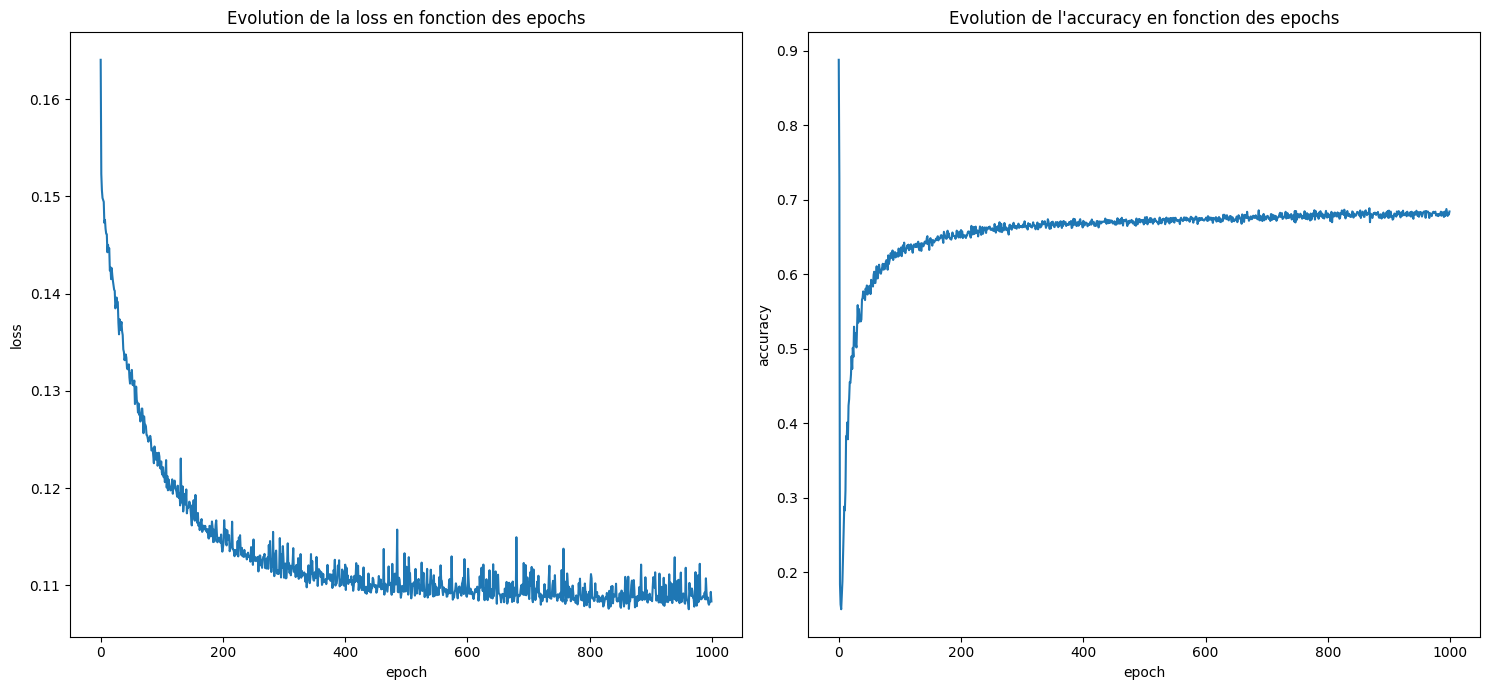

cuda
accuracy train:  0.6991251353864316


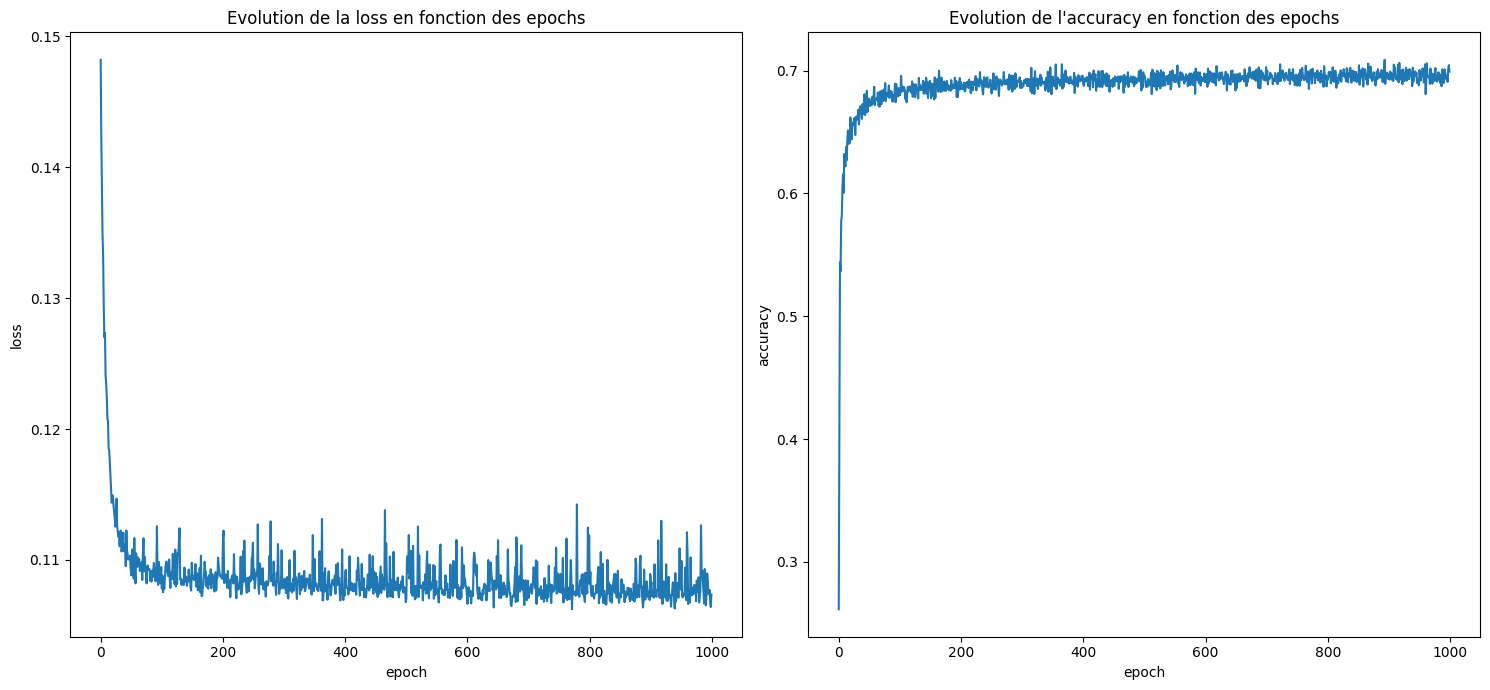

cuda
accuracy train:  0.7077886705045346


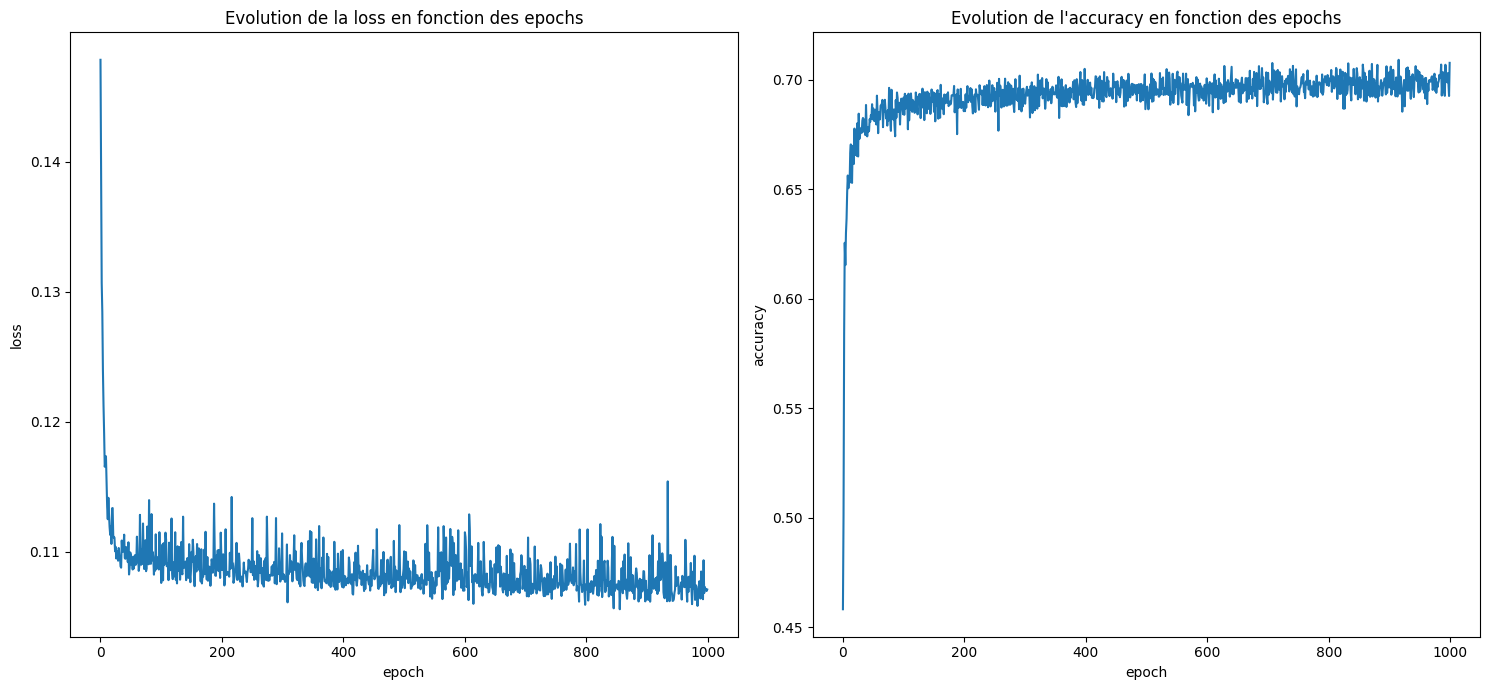

In [8]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [11]:
model = models[2]
torch.save(model.state_dict(), "model_near_HMDB.pth")

Accuracy test:  0.7131
Séparabilité:


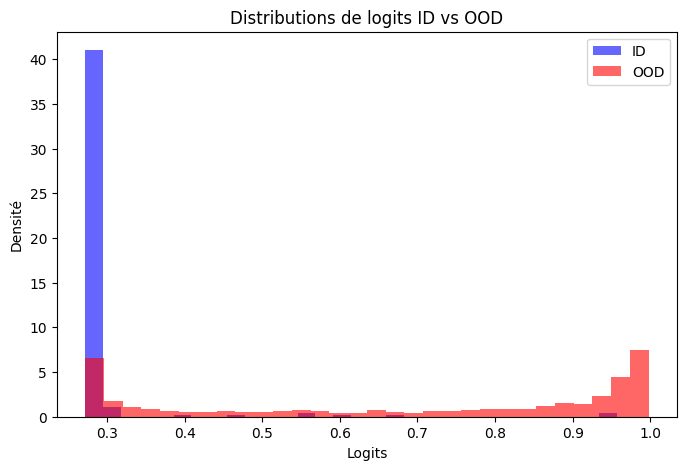

AUC ROC: 0.9474
FPR@TPR95: 0.2427



In [20]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"), correlations=False)

## UCF

In [21]:
data = data_all["UCF"]
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 
input_dim = 7 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data['y_train'], return_counts=True) ### Entrainement avec pondération)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

6116 elements (array([0., 1.], dtype=float32), array([ 824, 5292]))
1530 elements (array([0., 1.], dtype=float32), array([ 206, 1324]))


0.15570672713529857

cuda
accuracy train:  0.7316015623509884


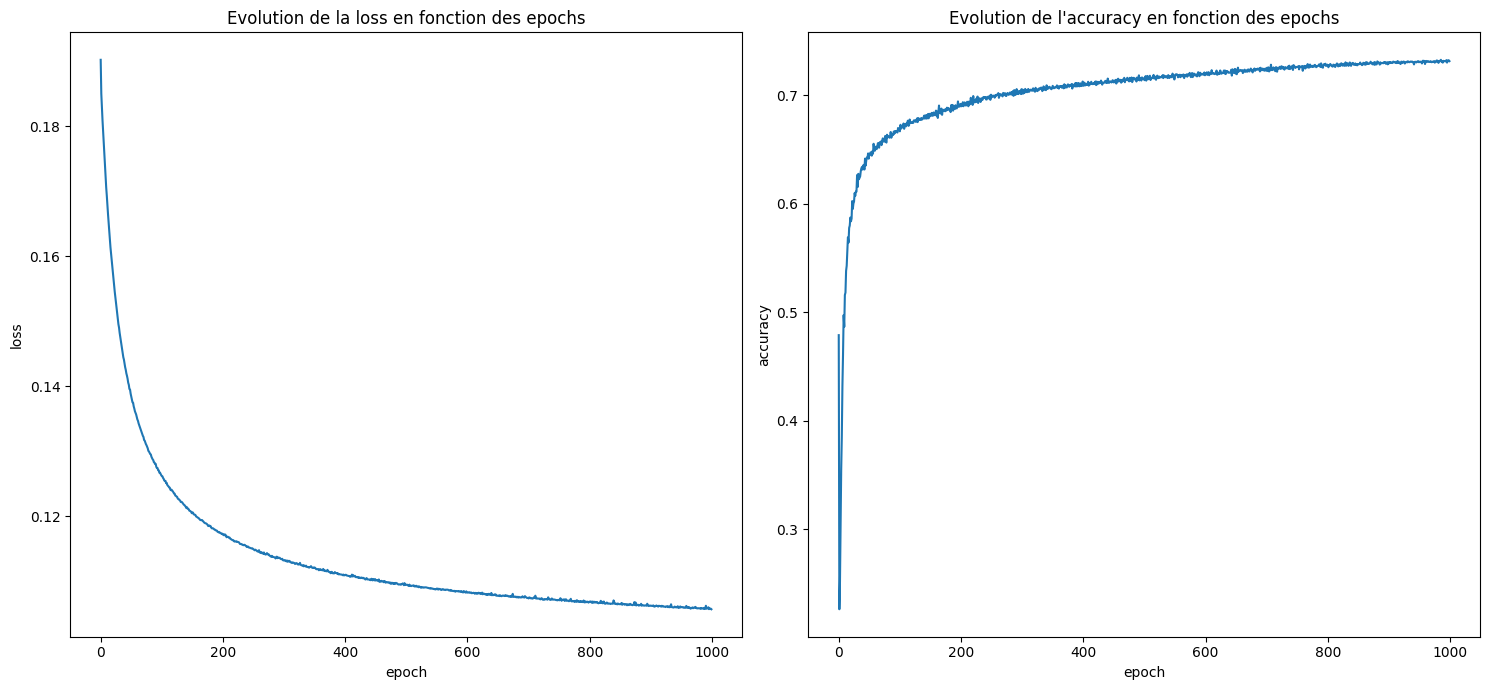

cuda
accuracy train:  0.7613020824889342


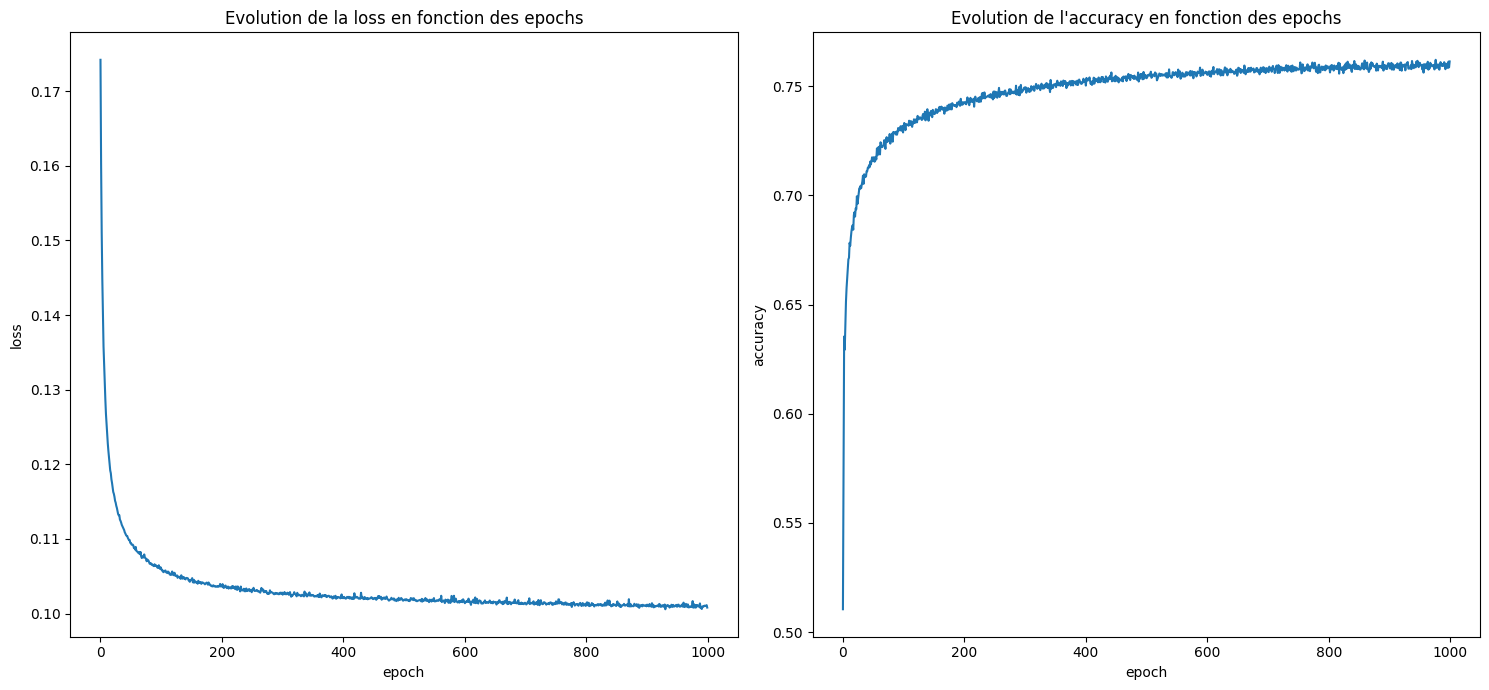

cuda
accuracy train:  0.7640885412693024


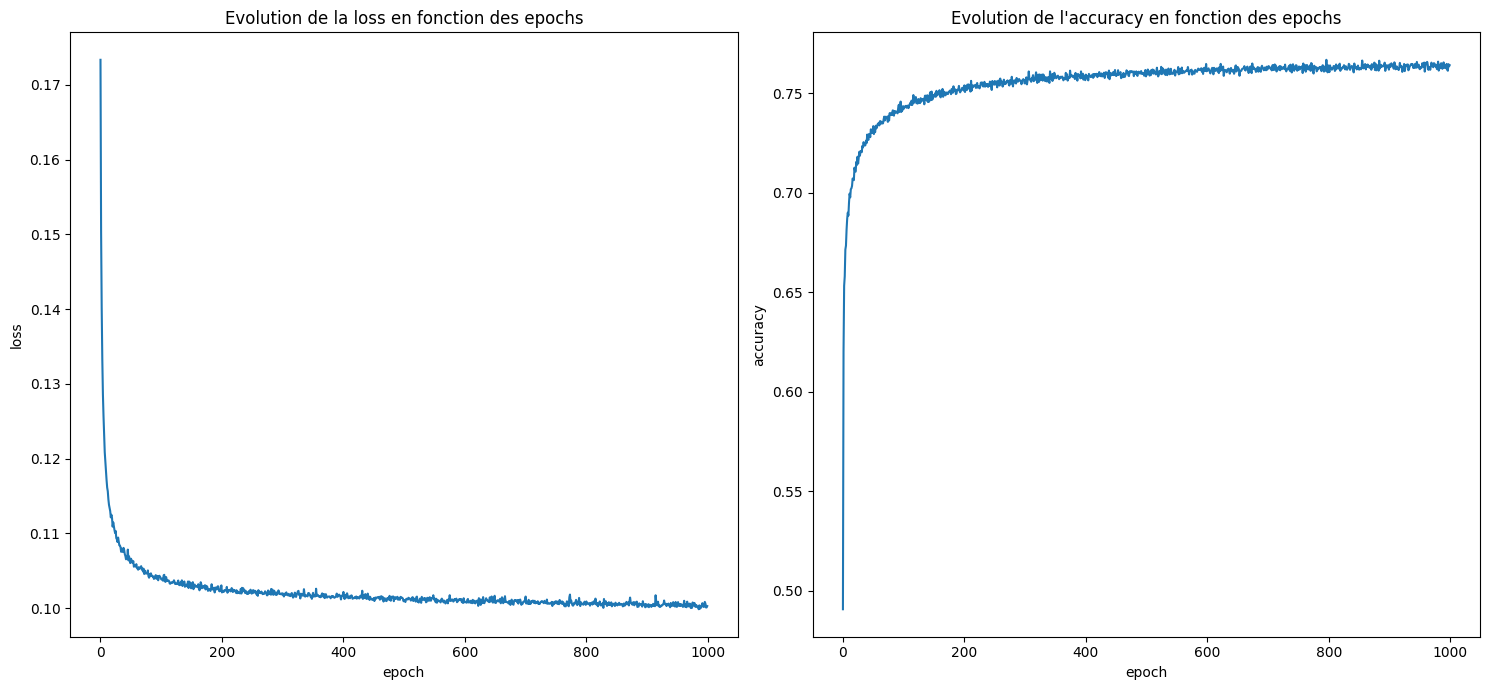

In [22]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [ ]:
model = models[2]
torch.save(model.state_dict(), "model_near_UCF.pth")

Accuracy test:  0.7686
Séparabilité:


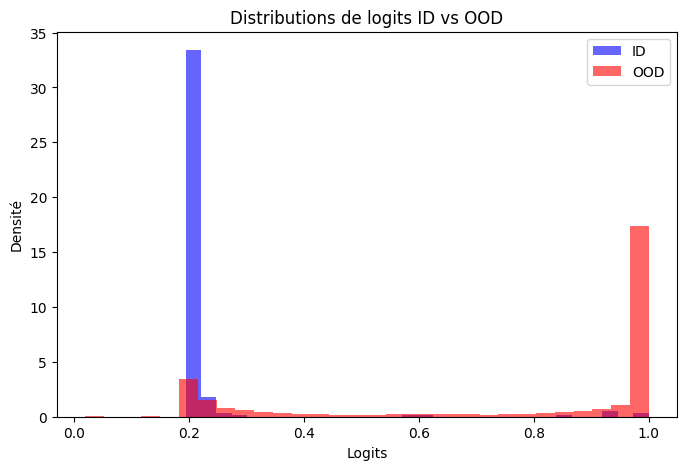

AUC ROC: 0.9458
FPR@TPR95: 0.2573



In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"), correlations=False)

## EPIC

In [25]:
data = data_all["EPIC"]
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 
input_dim = 7 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data['y_train'], return_counts=True) ### Entrainement avec pondération)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))
372 elements (array([0., 1.], dtype=float32), array([107, 265]))


0.4066350710900474

cuda
accuracy train:  0.5121642003456751


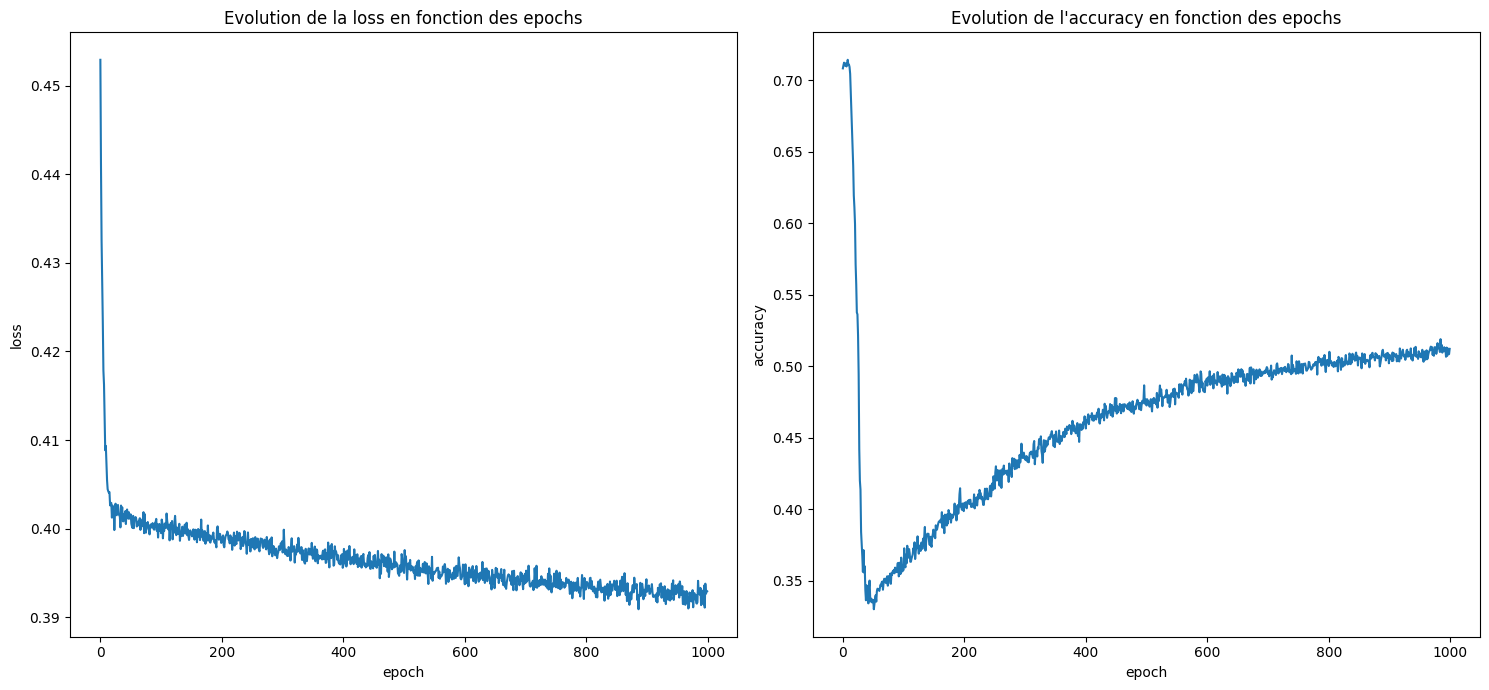

cuda
accuracy train:  0.5637335528930029


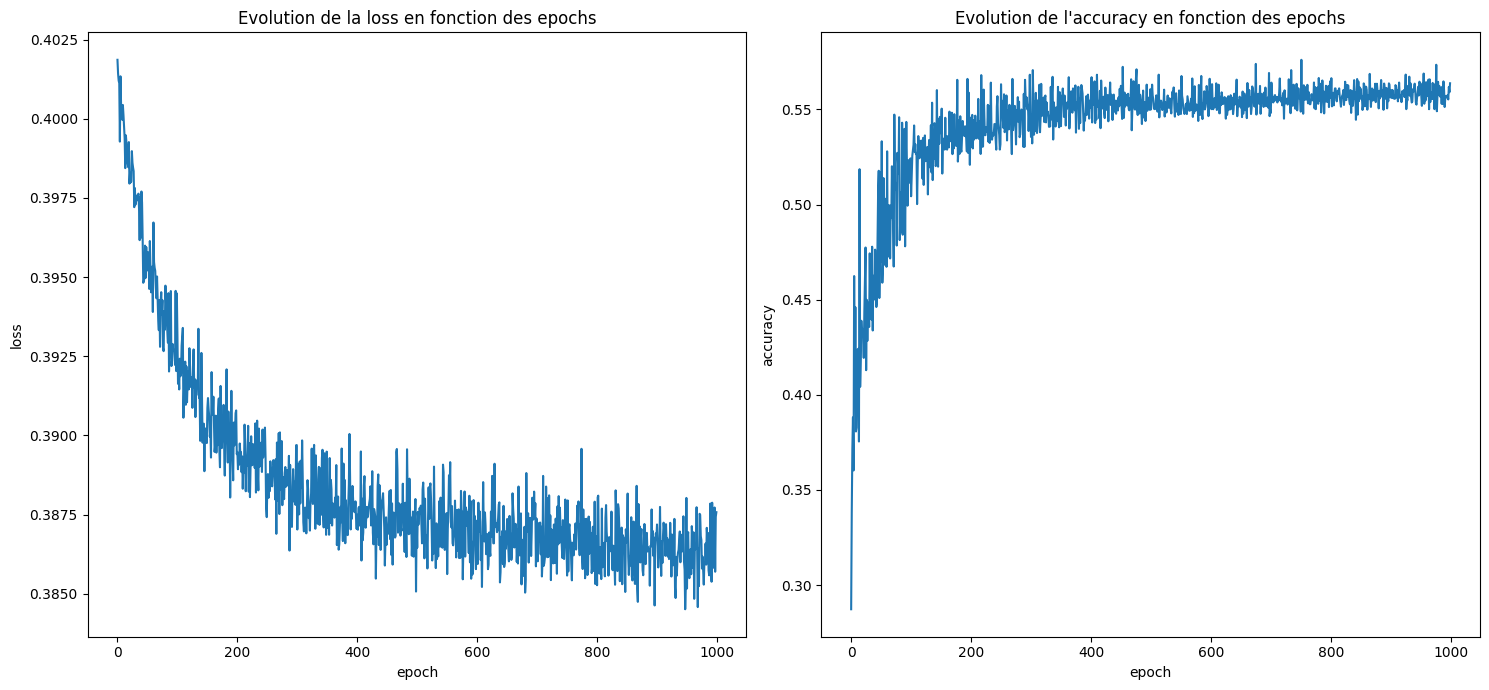

cuda
accuracy train:  0.5797697355349859


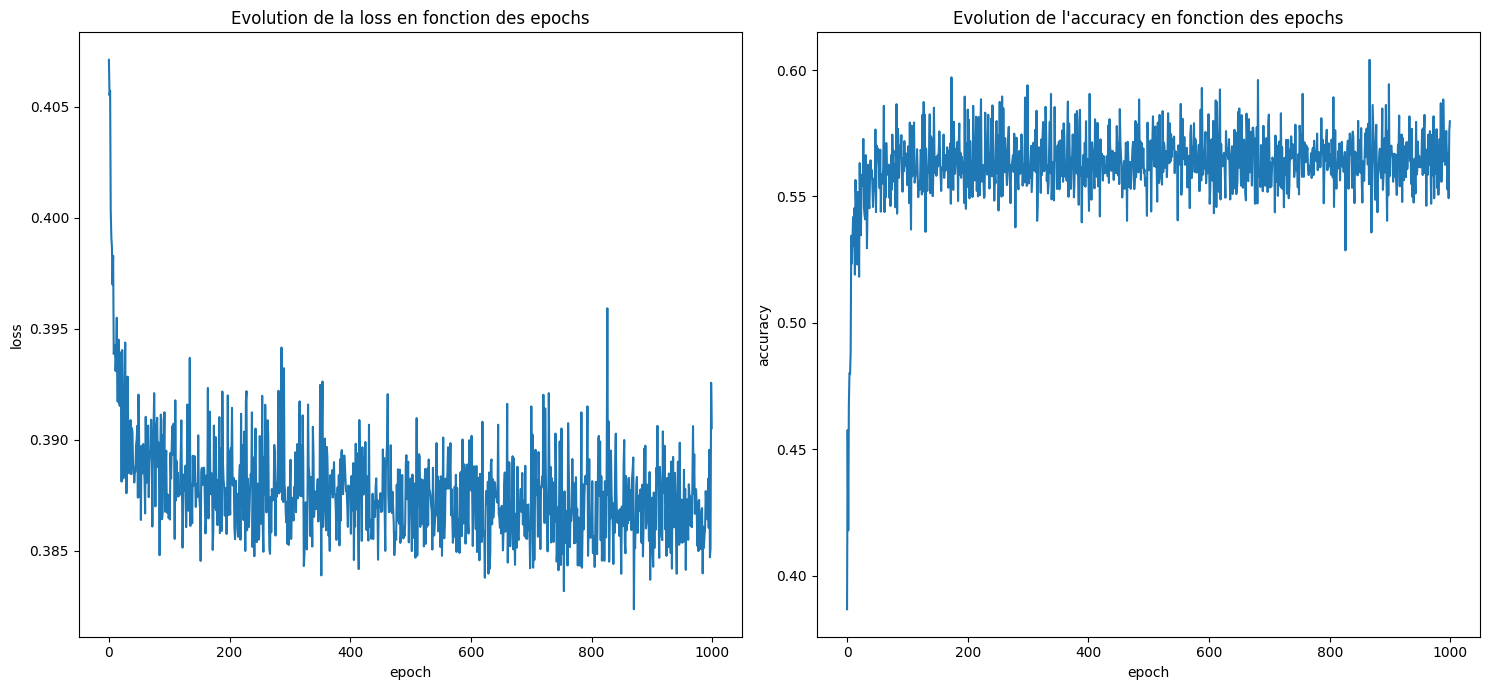

In [28]:
nb_epochs = 1000
models = {}
for lr in [1e-2, 1e-1, 1]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [ ]:
model = models[1]
torch.save(model.state_dict(), "model_near_EPIC.pth")

Accuracy test:  0.4462
Séparabilité:


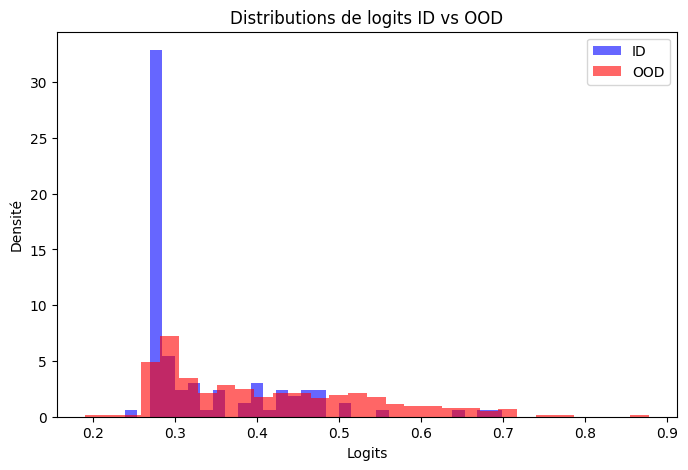

AUC ROC: 0.7223
FPR@TPR95: 0.7383



In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"), correlations=False)

# Near VFA

In [31]:
with open('../_classifieur/classif_react/data_vfa.pkl', 'rb') as f:
    data_react = pickle.load(f)

with open('../_classifieur/classif_ash/data_vfa.pkl', 'rb') as f:
    data_ash = pickle.load(f)
    

data["X_train"] = np.hstack([data_react["X_train"], data_ash["X_train"][:,1:]])
data["X_test"] = np.hstack([data_react["X_test"], data_ash["X_test"][:,1:]])
data["y_train"], data["y_test"] = data_ash["y_train"], data_ash["y_test"]

with open('data_vfa_ar.pkl', 'wb') as f:
    pickle.dump(data, f)

In [34]:
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 
input_dim = 9 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data['y_train'], return_counts=True) ### Entrainement avec pondération)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))
372 elements (array([0., 1.], dtype=float32), array([107, 265]))


0.4066350710900474

cuda
accuracy train:  0.585663378238678


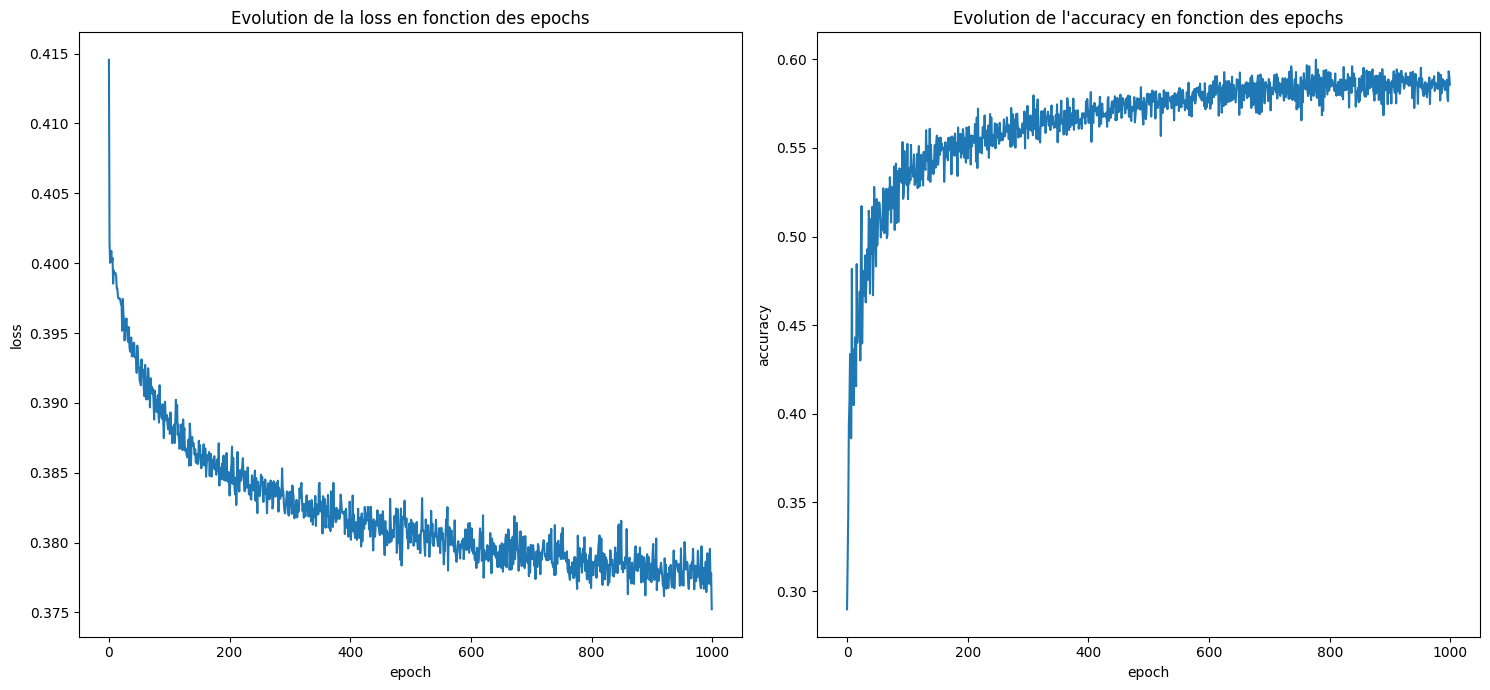

cuda
accuracy train:  0.5943325112263361


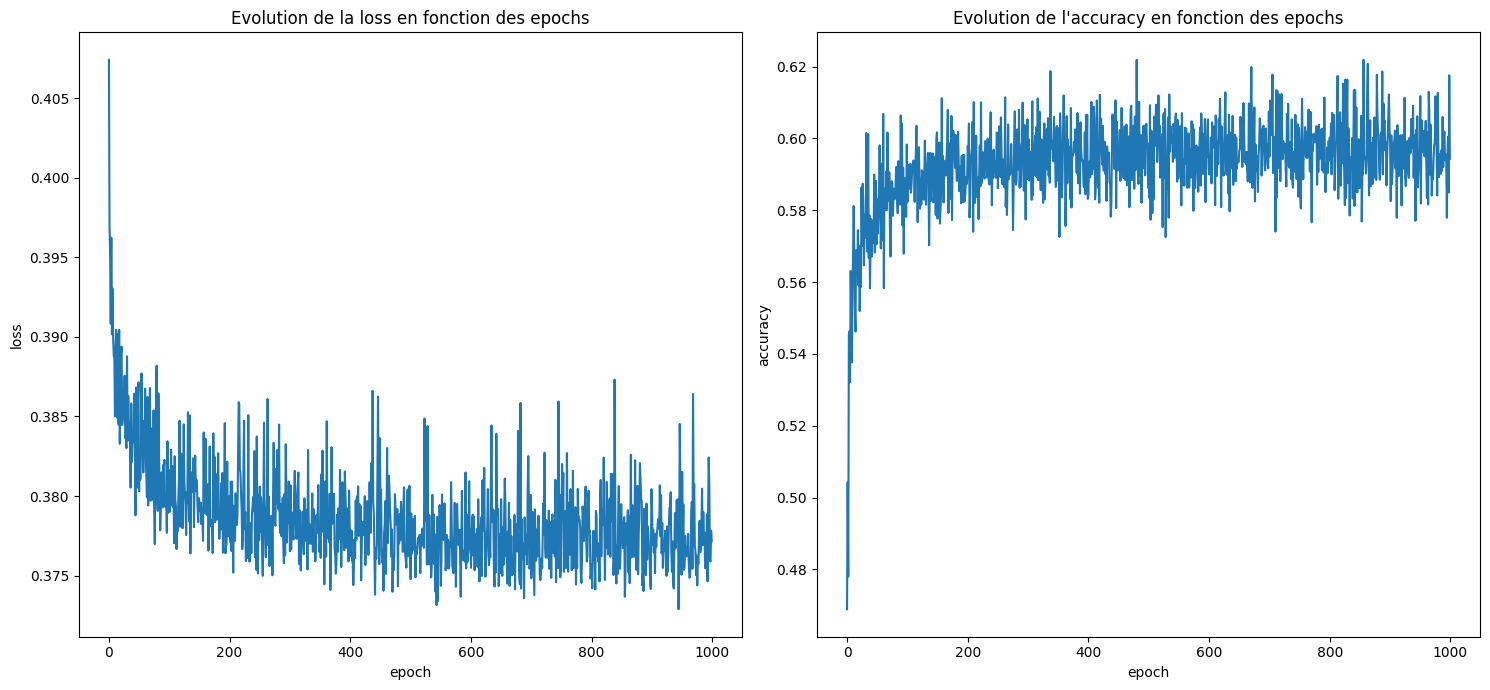

cuda
accuracy train:  0.5547560304403305


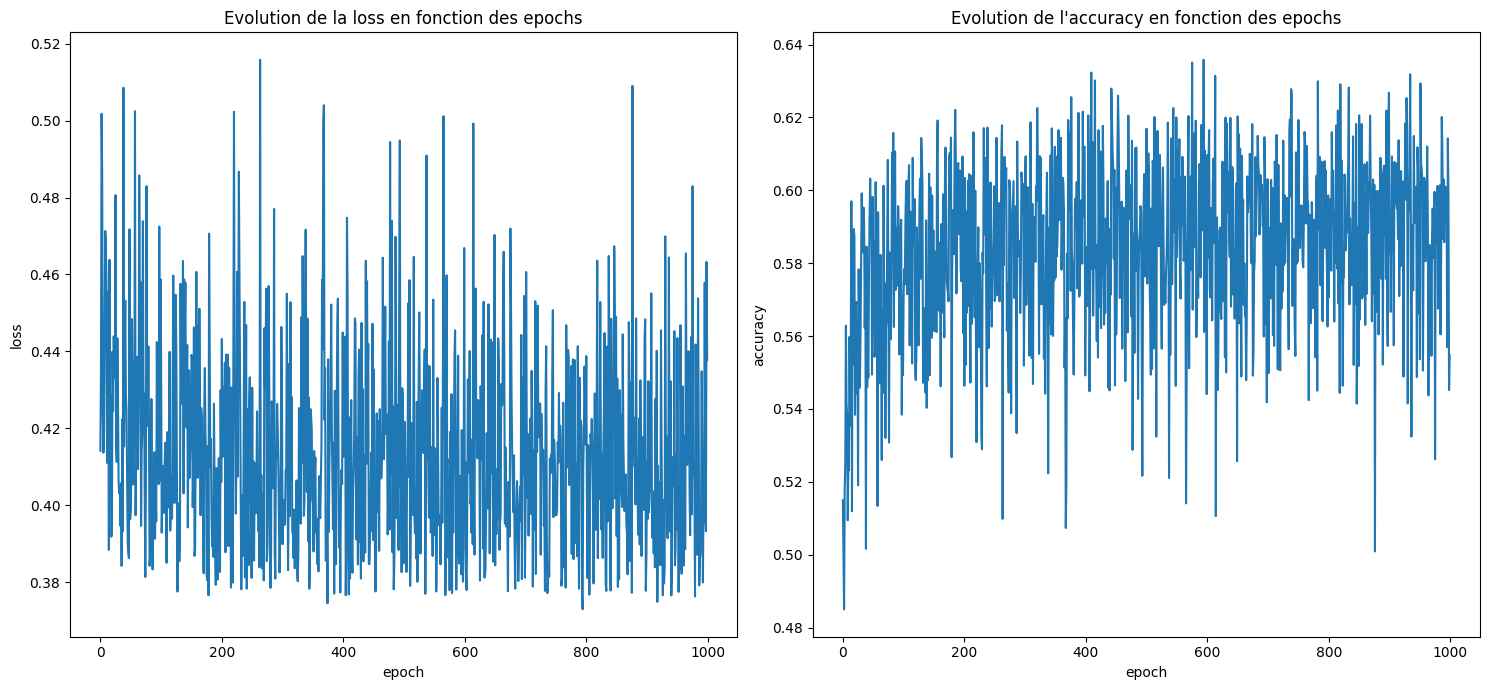

In [35]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [36]:
model = models[1]
torch.save(model.state_dict(), "model_vfa.pth")

Accuracy test:  0.5995
Séparabilité:


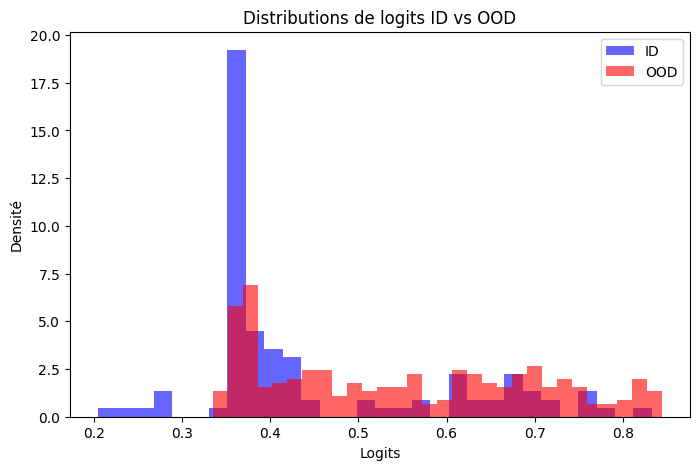

AUC ROC: 0.7052
FPR@TPR95: 0.785



In [37]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"), correlations=False)